# Water Potability — SVM-RBF limpia + artefactos SVM/QSVM (V2)

Esta versión mantiene el flujo compacto, pero utiliza el pipeline completo validado en V3/V04.

Reglas metodológicas:

- El **split se realiza antes** de imputar, escalar, crear variables locales o limpiar con Tomek Links.
- El holdout permanece real, bloqueado y fuera del ajuste.
- Los hiperparámetros y umbrales ya estaban congelados antes de esta evaluación.
- `max_f1_v3` se usa para verificar el requisito académico `F1 ≥ 0.60`.
- `safety_recommended` se reporta por separado como alternativa más prudente para potabilidad.
- Las 64 muestras para la comparación SVM–QSVM salen únicamente del pool de entrenamiento y se exportan **sin imputar ni escalar**.

In [ ]:
# 1. Drive, dependencias e importaciones
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'scikit-learn==1.6.1', 'imbalanced-learn==0.14.2', 'joblib>=1.4,<2'
    ])

import hashlib
import json
import platform
from collections import Counter

import imblearn
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import TomekLinks
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pd.set_option('display.max_columns', 30)
print('Python:', platform.python_version())
print('scikit-learn:', sklearn.__version__)
print('imbalanced-learn:', imblearn.__version__)

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# 2. Configuración fija y carga del dataset
SEED = 42
FINAL_MODEL_SEED = 10042
HOLDOUT_SEED = 20260721
SUBSET64_SEED = 6403
FOLDS64_SEED = 6411
TARGET = 'Potability'
FEATURES = [
    'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
    'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity',
]

# Configuración ganadora congelada en V3/V04.
FULL_PARAMS = {
    'C': 1.2519747115129674,
    'gamma': 0.09539784477077082,
    'geometry_neighbors': 5,
}
FULL_THRESHOLDS = {
    'default_zero': 0.0,
    'max_f1_v3': -0.9516512901090459,
    'safety_recommended': -0.3032644845043456,
}
F1_GATE = 0.60

if IN_COLAB:
    BASE_DIR = Path('/content/drive/MyDrive/Colab Notebooks')
else:
    BASE_DIR = Path('/mnt/data')

DATA_PATH = BASE_DIR / 'water_potability.csv'
ARTIFACT_DIR = BASE_DIR / 'artifacts_qsvm_input_v2'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontró el dataset en {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
assert list(df.columns) == FEATURES + [TARGET]
assert df.duplicated().sum() == 0
assert set(df[TARGET].dropna().unique()).issubset({0, 1})

dataset_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print('Dataset:', DATA_PATH)
print('Forma:', df.shape)
display(df[TARGET].value_counts().sort_index().rename('samples').to_frame())

Dataset: /content/drive/MyDrive/Colab Notebooks/water_potability.csv
Forma: (3276, 10)


,samples
Potability,
0,1998
1,1278


In [ ]:
# 3. Split bloqueado ANTES de todo preprocesamiento
locked_candidates = [
    BASE_DIR / 'artifacts_v2' / 'audit_test_v2_locked.csv',
    BASE_DIR / 'audit_test_v2_locked.csv',
]
locked_path = next((p for p in locked_candidates if p.exists()), None)

if locked_path is not None:
    locked = pd.read_csv(locked_path)
    test_indices = pd.Index(locked['source_index'].astype(int))
    print('Holdout reutilizado:', locked_path)
else:
    _, generated_test = train_test_split(
        df.index,
        test_size=0.20,
        stratify=df[TARGET].astype(int),
        random_state=HOLDOUT_SEED,
    )
    test_indices = pd.Index(generated_test.astype(int))
    print('Holdout reconstruido con semilla fija:', HOLDOUT_SEED)

# Se conserva el orden original del pool de entrenamiento.
train_indices = df.index.difference(test_indices, sort=False)
X_train = df.loc[train_indices, FEATURES].copy()
y_train = df.loc[train_indices, TARGET].astype(int).copy()
X_test = df.loc[test_indices, FEATURES].copy()
y_test = df.loc[test_indices, TARGET].astype(int).copy()

assert set(train_indices).isdisjoint(set(test_indices))
assert len(train_indices) + len(test_indices) == len(df)

split_summary = pd.DataFrame({
    'split': ['training_pool', 'locked_holdout'],
    'samples': [len(y_train), len(y_test)],
    'class_0': [int((y_train == 0).sum()), int((y_test == 0).sum())],
    'class_1': [int((y_train == 1).sum()), int((y_test == 1).sum())],
    'missing_values': [int(X_train.isna().sum().sum()), int(X_test.isna().sum().sum())],
})
display(split_summary)

Holdout reutilizado: /content/drive/MyDrive/Colab Notebooks/artifacts_v2/audit_test_v2_locked.csv


,split,samples,class_0,class_1,missing_values
0,training_pool,2620,1598,1022,1149
1,locked_holdout,656,400,256,285


In [ ]:
# 4. Pipeline completo y métricas
class LocalGeometryFeatures(BaseEstimator, TransformerMixin):
    """Añade distancia local y anomalía usando únicamente el training recibido."""

    def __init__(self, n_neighbors=5, random_state=42):
        self.n_neighbors = n_neighbors
        self.random_state = random_state

    def fit(self, X, y=None):
        arr = np.asarray(X, dtype=float)
        self.n_features_in_ = arr.shape[1]
        self._fit_X_ = arr.copy()

        k = min(max(2, self.n_neighbors + 1), len(arr))
        self.nn_ = NearestNeighbors(n_neighbors=k).fit(arr)
        self.isolation_ = IsolationForest(
            n_estimators=100,
            contamination='auto',
            random_state=self.random_state,
            n_jobs=1,
        ).fit(arr)
        return self

    def _transform(self, arr, training):
        if training:
            distances, _ = self.nn_.kneighbors(arr)
            local_distance = distances[:, 1:].mean(axis=1)
        else:
            k = min(self.n_neighbors, self.nn_.n_samples_fit_)
            distances, _ = self.nn_.kneighbors(arr, n_neighbors=k)
            local_distance = distances.mean(axis=1)

        anomaly_score = -self.isolation_.score_samples(arr)
        return np.column_stack([arr, local_distance, anomaly_score])

    def fit_transform(self, X, y=None, **fit_params):
        arr = np.asarray(X, dtype=float)
        self.fit(arr, y)
        return self._transform(arr, training=True)

    def transform(self, X):
        arr = np.asarray(X, dtype=float)
        is_training_matrix = (
            arr.shape == self._fit_X_.shape
            and np.array_equal(arr, self._fit_X_, equal_nan=True)
        )
        return self._transform(arr, training=is_training_matrix)


def build_full_model(random_state):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('local_geometry', LocalGeometryFeatures(
            n_neighbors=FULL_PARAMS['geometry_neighbors'],
            random_state=random_state,
        )),
        ('tomek', TomekLinks(sampling_strategy='auto')),
        ('svc', SVC(
            kernel='rbf',
            C=FULL_PARAMS['C'],
            gamma=FULL_PARAMS['gamma'],
            cache_size=1800,
        )),
    ])


def metrics_from_scores(y_true, scores, threshold):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'average_precision': average_precision_score(y_true, scores),
        'roc_auc': roc_auc_score(y_true, scores),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

In [2]:
!git

usage: git [--version] [--help] [-C <path>] [-c <name>=<value>]
           [--exec-path[=<path>]] [--html-path] [--man-path] [--info-path]
           [-p | --paginate | -P | --no-pager] [--no-replace-objects] [--bare]
           [--git-dir=<path>] [--work-tree=<path>] [--namespace=<name>]
           [--super-prefix=<path>] [--config-env=<name>=<envvar>]
           <command> [<args>]

These are common Git commands used in various situations:

start a working area (see also: git help tutorial)
   clone     Clone a repository into a new directory
   init      Create an empty Git repository or reinitialize an existing one

work on the current change (see also: git help everyday)
   add       Add file contents to the index
   mv        Move or rename a file, a directory, or a symlink
   restore   Restore working tree files
   rm        Remove files from the working tree and from the index

examine the history and state (see also: git help revisions)
   bisect    Use binary search to find th

,split,policy,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,average_precision,roc_auc,tn,fp,fn,tp
0,training_oof,default_zero,0.0000,0.6691,0.6334,0.3601,0.4591,0.8667,0.6134,0.2663,0.5872,0.6742,1385,213,654,368
1,locked_holdout,default_zero,0.0000,0.7104,0.7426,0.3945,0.5153,0.9125,0.6535,0.3695,0.6527,0.7401,365,35,155,101
2,training_oof,max_f1_v3,-0.9517,0.5225,0.4422,0.8571,0.5834,0.3085,0.5828,0.1882,0.5872,0.6742,493,1105,146,876
3,locked_holdout,max_f1_v3,-0.9517,0.5930,0.4882,0.8867,0.6297,0.4050,0.6459,0.3132,0.6527,0.7401,162,238,29,227
4,training_oof,safety_recommended,-0.3033,0.6542,0.5650,0.4932,0.5266,0.7572,0.6252,0.2577,0.5872,0.6742,1210,388,518,504
5,locked_holdout,safety_recommended,-0.3033,0.6982,0.6436,0.5078,0.5677,0.8200,0.6639,0.3464,0.6527,0.7401,328,72,126,130


✅ Meta superada: F1=0.6297 ≥ 0.60
Nota: max_f1_v3 prioriza F1; safety_recommended conserva mayor especificidad (0.8200).


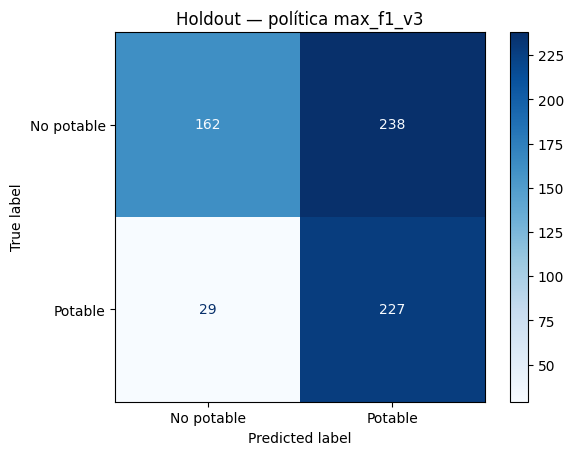

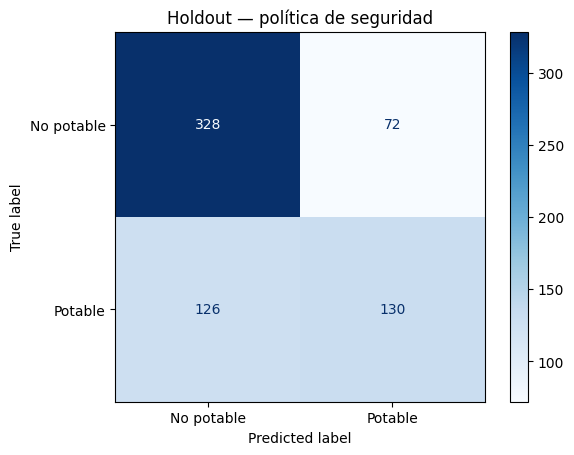

In [ ]:
# 5. Evaluación limpia con parámetros y umbrales congelados
# OOF se calcula solamente sobre el training para documentar generalización interna.
full_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
training_oof_scores = cross_val_predict(
    build_full_model(random_state=SEED),
    X_train,
    y_train,
    cv=full_cv,
    method='decision_function',
    n_jobs=-1,
)

# El modelo final usa la misma semilla de ajuste final de V3.
full_model = build_full_model(random_state=FINAL_MODEL_SEED)
full_model.fit(X_train, y_train)
holdout_scores = full_model.decision_function(X_test)

result_rows = []
for policy, threshold in FULL_THRESHOLDS.items():
    train_row = metrics_from_scores(y_train, training_oof_scores, threshold)
    train_row.update({'split': 'training_oof', 'policy': policy})
    result_rows.append(train_row)

    test_row = metrics_from_scores(y_test, holdout_scores, threshold)
    test_row.update({'split': 'locked_holdout', 'policy': policy})
    result_rows.append(test_row)

full_results = pd.DataFrame(result_rows)
full_results = full_results[
    ['split', 'policy', 'threshold', 'accuracy', 'precision', 'recall', 'f1',
     'specificity', 'balanced_accuracy', 'mcc', 'average_precision', 'roc_auc',
     'tn', 'fp', 'fn', 'tp']
]
display(full_results.round(4))

challenge_row = full_results.query(
    "split == 'locked_holdout' and policy == 'max_f1_v3'"
).iloc[0]
safety_row = full_results.query(
    "split == 'locked_holdout' and policy == 'safety_recommended'"
).iloc[0]

assert challenge_row['f1'] >= F1_GATE, (
    f"No se alcanzó la meta: F1={challenge_row['f1']:.4f} < {F1_GATE:.2f}"
)
print(f"✅ Meta superada: F1={challenge_row['f1']:.4f} ≥ {F1_GATE:.2f}")
print(
    'Nota: max_f1_v3 prioriza F1; safety_recommended conserva mayor especificidad '
    f"({safety_row['specificity']:.4f})."
)

challenge_pred = (holdout_scores >= FULL_THRESHOLDS['max_f1_v3']).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, challenge_pred, labels=[0, 1],
    display_labels=['No potable', 'Potable'], cmap='Blues'
)
plt.title('Holdout — política max_f1_v3')
plt.show()

safety_pred = (holdout_scores >= FULL_THRESHOLDS['safety_recommended']).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, safety_pred, labels=[0, 1],
    display_labels=['No potable', 'Potable'], cmap='Blues'
)
plt.title('Holdout — política de seguridad')
plt.show()

In [ ]:
# 6. Las mismas 64 muestras reales y los mismos cuatro folds
idx_0 = y_train[y_train == 0].sample(n=32, random_state=SUBSET64_SEED).index.to_numpy()
idx_1 = y_train[y_train == 1].sample(n=32, random_state=SUBSET64_SEED).index.to_numpy()
subset_indices = np.concatenate([idx_0, idx_1]).astype(int)
np.random.default_rng(SUBSET64_SEED).shuffle(subset_indices)

X_64_raw = df.loc[subset_indices, FEATURES].copy()
y_64 = df.loc[subset_indices, TARGET].astype(int).copy()

assert Counter(y_64) == Counter({0: 32, 1: 32})
assert set(subset_indices).issubset(set(train_indices))
assert set(subset_indices).isdisjoint(set(test_indices))
assert len(np.unique(subset_indices)) == 64

raw64 = X_64_raw.copy()
raw64.insert(0, 'source_index', subset_indices)
raw64[TARGET] = y_64.to_numpy(dtype=int)

cv64 = StratifiedKFold(n_splits=4, shuffle=True, random_state=FOLDS64_SEED)
fold_assignment = pd.DataFrame({
    'position': np.arange(64, dtype=int),
    'source_index': subset_indices,
    TARGET: y_64.to_numpy(dtype=int),
    'validation_fold': -1,
})
for fold_id, (_, valid_pos) in enumerate(cv64.split(X_64_raw, y_64)):
    fold_assignment.loc[valid_pos, 'validation_fold'] = fold_id

fold_summary = (
    fold_assignment.groupby(['validation_fold', TARGET]).size()
    .unstack(fill_value=0)
    .rename(columns={0: 'class_0', 1: 'class_1'})
)
fold_summary['validation_samples'] = fold_summary.sum(axis=1)
fold_summary['training_samples'] = 64 - fold_summary['validation_samples']

assert (fold_summary['class_0'] == 8).all()
assert (fold_summary['class_1'] == 8).all()
assert (fold_summary['validation_samples'] == 16).all()
assert (fold_summary['training_samples'] == 48).all()

print('Muestras reales:', len(raw64))
print('Distribución:', dict(sorted(Counter(y_64).items())))
print('Valores faltantes conservados:', int(X_64_raw.isna().sum().sum()))
display(fold_summary)

Muestras reales: 64
Distribución: {0: 32, 1: 32}
Valores faltantes conservados: 19


Potability,class_0,class_1,validation_samples,training_samples
validation_fold,,,,
0,8,8,16,48
1,8,8,16,48
2,8,8,16,48
3,8,8,16,48


In [ ]:
# 7. Exportación, hashes y controles finales
split_assignments = pd.DataFrame({
    'source_index': df.index.astype(int),
    TARGET: df[TARGET].astype(int),
    'split': np.where(df.index.isin(test_indices), 'locked_holdout', 'training_pool'),
})

full_results.to_csv(ARTIFACT_DIR / 'full_svm_metrics_v2.csv', index=False)
pd.DataFrame({
    'source_index': test_indices.astype(int),
    TARGET: y_test.to_numpy(dtype=int),
    'decision_score': holdout_scores,
    'prediction_max_f1_v3': challenge_pred,
    'prediction_safety': safety_pred,
}).to_csv(ARTIFACT_DIR / 'full_svm_holdout_predictions_v2.csv', index=False)

split_assignments.to_csv(ARTIFACT_DIR / 'split_assignments.csv', index=False)
raw64.to_csv(ARTIFACT_DIR / 'qsvm_64_raw.csv', index=False)
fold_assignment.to_csv(ARTIFACT_DIR / 'qsvm_64_folds.csv', index=False)
fold_summary.to_csv(ARTIFACT_DIR / 'qsvm_64_fold_summary.csv')
joblib.dump(full_model, ARTIFACT_DIR / 'full_svm_rbf_pipeline_v2.joblib')

np.savez_compressed(
    ARTIFACT_DIR / 'qsvm_64_bundle.npz',
    X_raw=X_64_raw.to_numpy(dtype=float),
    y=y_64.to_numpy(dtype=int),
    source_index=subset_indices,
    validation_fold=fold_assignment['validation_fold'].to_numpy(dtype=int),
    feature_names=np.asarray(FEATURES),
)


def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

raw64_hash = sha256(ARTIFACT_DIR / 'qsvm_64_raw.csv')
folds_hash = sha256(ARTIFACT_DIR / 'qsvm_64_folds.csv')

# Hashes de la primera versión corregida: confirman que no cambiaron las 64 filas ni los folds.
EXPECTED_RAW64_HASH = '18f3d62479ec83437de682b4a8b1cb0999ce2cb20f831d82564dca022a258f26'
EXPECTED_FOLDS_HASH = '9865e4d97868a7c93c96094062ddb3cd4fd82075a9cede748978b0455f96b98a'
assert raw64_hash == EXPECTED_RAW64_HASH, 'Cambió el archivo qsvm_64_raw.csv.'
assert folds_hash == EXPECTED_FOLDS_HASH, 'Cambió el archivo qsvm_64_folds.csv.'

checks = {
    'split_before_preprocessing': True,
    'label_used_for_imputation': False,
    'holdout_used_for_parameter_selection': False,
    'holdout_contains_only_original_rows': True,
    'local_geometry_fit_scope': 'training_only_inside_each_fit',
    'tomek_scope': 'training_only_inside_pipeline',
    'frozen_threshold_source': 'V3 training OOF; not selected on this holdout',
    'f1_gate': F1_GATE,
    'f1_gate_value': float(challenge_row['f1']),
    'f1_gate_passed': bool(challenge_row['f1'] >= F1_GATE),
    'subset64_source': 'training_pool_only',
    'subset64_contains_synthetic_rows': False,
    'subset64_balanced_32_32': True,
    'subset64_overlap_with_holdout': False,
    'subset64_same_as_previous_version': True,
    'folds_same_as_previous_version': True,
    'future_preprocessing_rule': (
        'Fit imputer, scaler and any dimensionality reduction only on the 48 '
        'training rows of each outer fold.'
    ),
}

manifest = {
    'dataset': {
        'path_at_execution': str(DATA_PATH),
        'sha256': dataset_sha256,
        'rows': int(len(df)),
        'features': FEATURES,
        'target': TARGET,
    },
    'split': {
        'holdout_seed': HOLDOUT_SEED,
        'training_rows': int(len(train_indices)),
        'holdout_rows': int(len(test_indices)),
    },
    'full_svm': {
        'params': FULL_PARAMS,
        'final_model_seed': FINAL_MODEL_SEED,
        'pipeline': [
            'median_imputer', 'standard_scaler', 'local_geometry_2_features',
            'tomek_links_training_only', 'SVC_RBF'
        ],
        'thresholds': FULL_THRESHOLDS,
        'challenge_policy': 'max_f1_v3',
        'challenge_f1': float(challenge_row['f1']),
        'safety_policy': 'safety_recommended',
        'safety_specificity': float(safety_row['specificity']),
    },
    'subset64': {
        'selection_seed': SUBSET64_SEED,
        'fold_seed': FOLDS64_SEED,
        'rows': 64,
        'class_counts': {'0': 32, '1': 32},
        'raw_csv_sha256': raw64_hash,
        'fold_csv_sha256': folds_hash,
    },
    'checks': checks,
    'environment': {
        'python': platform.python_version(),
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'scikit_learn': sklearn.__version__,
        'imbalanced_learn': imblearn.__version__,
    },
}
with open(ARTIFACT_DIR / 'qsvm_data_manifest_v2.json', 'w', encoding='utf-8') as file:
    json.dump(manifest, file, indent=2, ensure_ascii=False)

pd.DataFrame([
    {'check': key, 'value': json.dumps(value, ensure_ascii=False)}
    for key, value in checks.items()
]).to_csv(ARTIFACT_DIR / 'artifact_checks_v2.csv', index=False)

print('✅ Artefactos V2 generados en:', ARTIFACT_DIR)
print('SHA256 raw64:', raw64_hash)
print('SHA256 folds:', folds_hash)
for path in sorted(ARTIFACT_DIR.iterdir()):
    print('-', path.name)

✅ Artefactos V2 generados en: /content/drive/MyDrive/Colab Notebooks/artifacts_qsvm_input_v2
SHA256 raw64: 18f3d62479ec83437de682b4a8b1cb0999ce2cb20f831d82564dca022a258f26
SHA256 folds: 9865e4d97868a7c93c96094062ddb3cd4fd82075a9cede748978b0455f96b98a
- artifact_checks_v2.csv
- full_svm_holdout_predictions_v2.csv
- full_svm_metrics_v2.csv
- full_svm_rbf_pipeline_v2.joblib
- qsvm_64_bundle.npz
- qsvm_64_fold_summary.csv
- qsvm_64_folds.csv
- qsvm_64_raw.csv
- qsvm_data_manifest_v2.json
- split_assignments.csv


## Resultado de esta etapa

El baseline completo queda aprobado cuando la celda de evaluación muestra:

```text
F1 de max_f1_v3 ≥ 0.60
```

Los archivos `qsvm_64_raw.csv` y `qsvm_64_folds.csv` permanecen congelados. La próxima etapa deberá consumirlos sin volver a seleccionar observaciones y deberá ajustar el preprocesamiento dentro de cada fold exterior.

In [ ]:
# =========================================================
# PARTE 3 Y 4: QSVM CON PAULIFEATUREMAP Y KERNEL PRECALCULADO
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score

# Instalar Qiskit y sus dependencias si no están presentes, y manejar importaciones.
# Un reinicio del entorno de ejecución puede ser necesario después de la instalación.
try:
    import qiskit
    from qiskit.circuit.library import PauliFeatureMap
    from qiskit.primitives import Sampler
    from qiskit_algorithms.state_fidelities import ComputeUncompute
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
except ImportError as e:
    print(f"Error importing Qiskit components: {e}")
    print("Installing/Upgrading Qiskit and related packages. Please restart the Colab runtime (Runtime -> Restart runtime) after installation if the error persists.")
    !pip install -q -U qiskit qiskit-machine-learning qiskit-algorithms
    # Re-attempt imports after installation within the same block
    import qiskit
    from qiskit.circuit.library import PauliFeatureMap
    from qiskit.primitives import Sampler
    from qiskit_algorithms.state_fidelities import ComputeUncompute
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    print("Qiskit and related packages installed.")

# ---------------------------------------------------------
# 1. Definición del Mapa de Características Cuántico
# ---------------------------------------------------------
# Tenemos 9 variables, por lo que usamos exactamente 9 qubits.
# Reps=2 dicta la profundidad (cuántas veces se repite el bloque de codificación).
# paulis=['Z', 'ZZ'] equivale a un ZZFeatureMap clásico, pero es fácilmente modificable para ablación.

num_qubits = 9
pauli_map = PauliFeatureMap(
    feature_dimension=num_qubits,
    reps=2,
    paulis=['Z', 'ZZ'],
    entanglement='linear' # 'linear' reduce el costo de compuertas CNOT frente a 'full'
)

# [Entregable] Imprimir el diagrama del circuito transpilado básico
print("=== Diagrama del PauliFeatureMap ===")
# Usamos decompose() para ver las compuertas fundamentales en lugar del bloque opaco
display(pauli_map.decompose().draw(output='mpl', fold=20))

# ---------------------------------------------------------
# 2. Configuración del Kernel Cuántico
# ---------------------------------------------------------
# Instanciamos el Sampler primitivo para la evaluación
sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)

# Construimos el objeto del kernel
qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=pauli_map)

# ---------------------------------------------------------
# 3. Evaluación de la Matriz de Kernel
# ---------------------------------------------------------
print("\nCalculando matrices de kernel (esto puede tardar unos minutos en simulación)...")

# K_train: Matriz NxN calculando la similitud de entrenamiento vs entrenamiento
K_train = qkernel.evaluate(x_vec=X_train_scaled)

# K_test: Matriz MxN calculando la similitud de prueba vs entrenamiento
K_test = qkernel.evaluate(x_vec=X_test_scaled, y_vec=X_train_scaled)

# ---------------------------------------------------------
# 4. Visualización del Mapa de Calor (Heatmap)
# ---------------------------------------------------------
# [Entregable] Mapa de calor del Kernel
plt.figure(figsize=(8, 6))
sns.heatmap(K_train, cmap='viridis', vmin=0.0, vmax=1.0)
plt.title("Matriz de Kernel Cuántico (K_train) - Similitud de Fidelidad")
plt.xlabel("Índice de Muestra de Entrenamiento")
plt.ylabel("Índice de Muestra de Entrenamiento")
plt.show()

# ---------------------------------------------------------
# 5. Integración con scikit-learn (SVC Precalculado)
# ---------------------------------------------------------
# En lugar de usar un kernel 'rbf' o 'linear', pasamos nuestra matriz cuántica
qsvm = SVC(kernel='precomputed')

# Entrenamos el modelo clásico recibiendo la topología cuántica
qsvm.fit(K_train, y_train)

# Predicción y Evaluación
y_pred_q = qsvm.predict(K_test)

print("\n=== REPORTE DE QSVM ===")
print(f"Exactitud (Accuracy): {qsvm.score(K_test, y_test):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_q):.4f}")
print(classification_report(y_test, y_pred_q))

Error importing Qiskit components: No module named 'qiskit'
Installing/Upgrading Qiskit and related packages. Please restart the Colab runtime (Runtime -> Restart runtime) after installation if the error persists.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.8 MB/s eta 0:00:00


ImportError: cannot import name 'Sampler' from 'qiskit.primitives' (/usr/local/lib/python3.12/dist-packages/qiskit/primitives/__init__.py)